#### 1. Setup

In [1]:
from pathlib import Path

FIGURES_DIR = Path("../documentation/figures/eda")
REPORT_PATH = Path("../documentation/eda_report.md")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Darstellungsoptionen
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Setup abgeschlossen.")

Setup abgeschlossen.


#### 2. Import
- OSMI Mental Health in Tech Survey 2016 
- https://www.kaggle.com/osmi/mental-health-in-tech-2016

In [2]:
df_raw = pd.read_csv("../data/raw/mental-health-in-tech-2016_20161114.csv")
print(f"Eingelesene Zeilen: {df_raw.shape[0]}")
df_raw = df_raw.map(lambda x: x.replace("\n", " ") if isinstance(x, str) else x)
df_raw.to_csv("../data/processed/mental-health-in-tech-2016_clean.csv", index=False, lineterminator="\n")
df = pd.read_csv("../data/processed/mental-health-in-tech-2016_clean.csv")
print(f"Datensatz geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

Eingelesene Zeilen: 1433
Datensatz geladen: 1433 Zeilen, 63 Spalten


In [3]:
sys.path.append("../src")
from column_aliases import COLUMN_ALIASES

df.rename(columns={k: v for k, v in COLUMN_ALIASES.items() if k in df.columns}, inplace=True)
if "Why or why not?.1" in df.columns:
    df.rename(columns={"Why or why not?.1": "interview_mental_why"}, inplace=True)

#### 3. Datenstruktur

- Spaltennamen + 3 Zeilen

In [4]:
df.head(3)

,self_employed,company_size,tech_company,tech_role,mh_benefits,know_options,employer_discussed_mh,employer_resources,anonymity_protected,leave_difficulty,neg_consequences_employer,neg_consequences_physical,comfortable_coworkers,comfortable_supervisor,employer_takes_mh_serious,observed_neg_consequences,medical_coverage,know_resources,reveal_clients,reveal_clients_impact,reveal_coworkers,reveal_coworkers_impact,productivity_affected,pct_work_affected,has_previous_employers,prev_mh_benefits,prev_aware_options,prev_discussed_mh,prev_resources,prev_anonymity,prev_neg_consequences,prev_neg_physical,prev_comfortable_coworkers,prev_comfortable_supervisor,prev_mh_serious,prev_observed_neg,interview_physical,interview_physical_why,interview_mental,interview_mental_why,mh_hurts_career,coworkers_view_neg,share_friends_family,observed_bad_response,observations_less_likely,family_history,past_disorder,current_disorder,diagnosed_conditions,believed_conditions,professionally_diagnosed,professional_diagnosis_detail,sought_treatment,interferes_treated,interferes_untreated,age,gender,country_live,us_state_live,country_work,us_state_work,work_position,remote_work
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,NaN,Maybe,NaN,Maybe,"No, I don't think they would",Somewhat open,No,NaN,No,Yes,No,NaN,NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia, etc)",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there is a health issue that would n...,No,"While mental health has become a more prominent issue recently, I feel like ...","No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depressio...",NaN,Yes,"Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depressio...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if I can do my job or not.",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,NaN,NaN,No,NaN,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   self_employed                  1433 non-null   int64  
 1   company_size                   1146 non-null   str    
 2   tech_company                   1146 non-null   float64
 3   tech_role                      263 non-null    float64
 4   mh_benefits                    1146 non-null   str    
 5   know_options                   1013 non-null   str    
 6   employer_discussed_mh          1146 non-null   str    
 7   employer_resources             1146 non-null   str    
 8   anonymity_protected            1146 non-null   str    
 9   leave_difficulty               1146 non-null   str    
 10  neg_consequences_employer      1146 non-null   str    
 11  neg_consequences_physical      1146 non-null   str    
 12  comfortable_coworkers          1146 non-null   str    
 13 

#### Spaltennamen kürzen

#### 4. Fehlende Werte

- Fragen wurden nicht beantwortet
- Selbstständige haben keinen Arbeitgeber, Antworten fehlen
- Einige Fragen werden nur bestimmten Personen gestellt (?)

#### Analyse
- Einige Spalten haben exakt 287 fehlende Werte (20%)
- entspricht der Anzahl der Selbstständigen im Datensatz (`self_employed == 1`). 
- 169 Personen hatten / nennen keine früheren Arbeitgeber (`has_previous_employers == 0`), 
- da wo mehr als der Werte fehlen (`reveal_clients`, `productivity_affected`) wurden die Fragen vermutlich nicht gestellt -> im Preprocessing entfernen?

In [6]:
# Fehlende Werte pro Spalte
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Fehlend': missing,
    'Prozent': missing_pct
}).sort_values('Fehlend', ascending=False)

# Nur Spalten mit fehlenden Werten anzeigen
missing_df[missing_df['Fehlend'] > 0]

,Fehlend,Prozent
reveal_clients_impact,1289,90.0
pct_work_affected,1229,85.8
tech_role,1170,81.6
medical_coverage,1146,80.0
reveal_clients,1146,80.0
reveal_coworkers,1146,80.0
reveal_coworkers_impact,1146,80.0
know_resources,1146,80.0
productivity_affected,1146,80.0
believed_conditions,1111,77.5


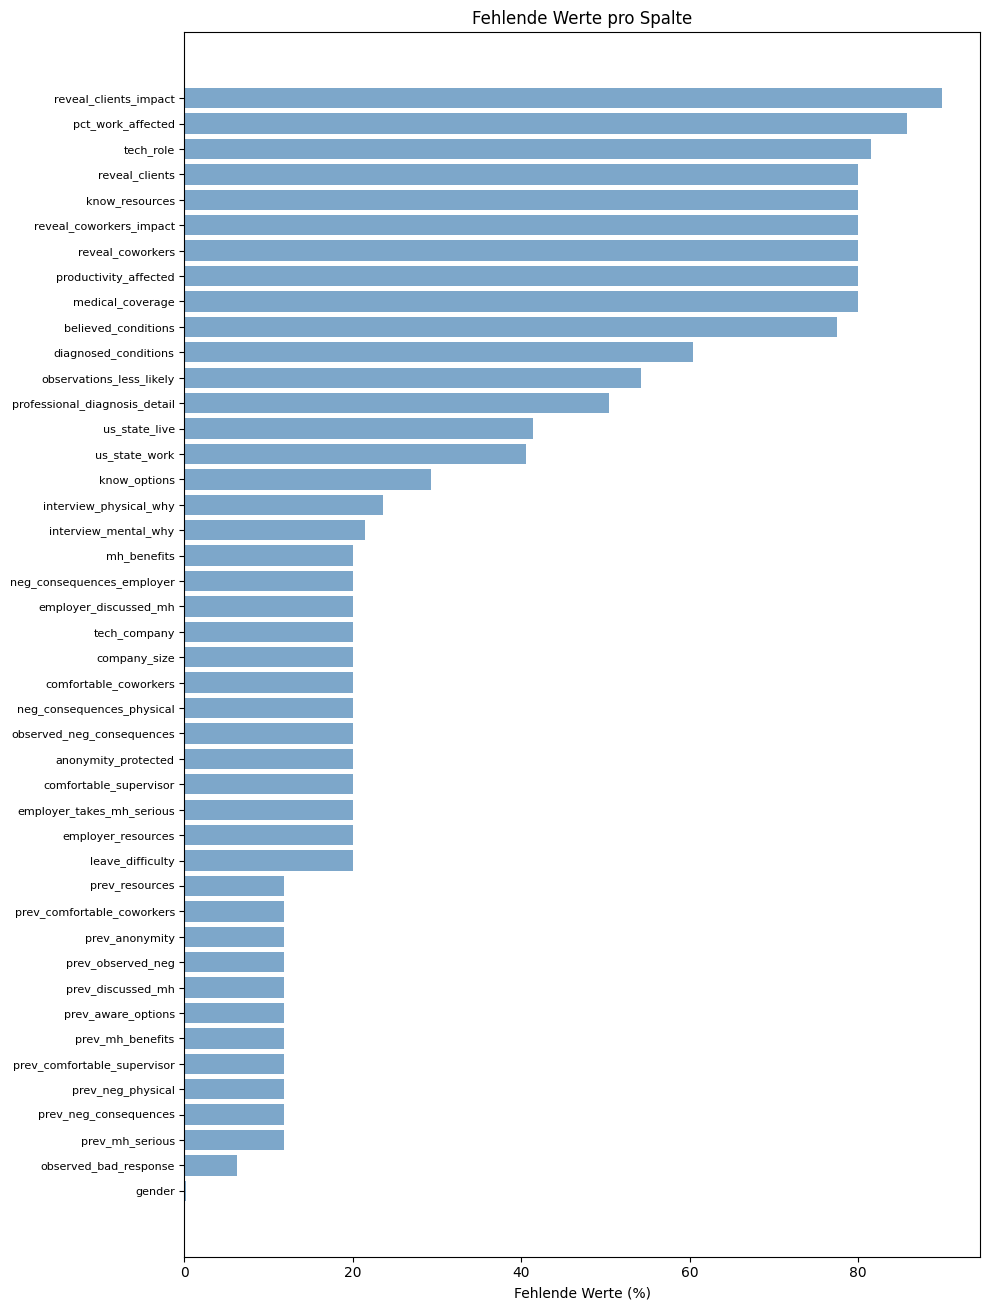

In [7]:
# Fehlende Werte, Verteilung
missing_plot = missing_df[missing_df['Fehlend'] > 0].sort_values('Fehlend', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(missing_plot) * 0.3)))
ax.barh(range(len(missing_plot)), missing_plot['Prozent'], color='steelblue', alpha=0.7)
ax.set_yticks(range(len(missing_plot)))
ax.set_yticklabels(missing_plot.index, fontsize=8)
ax.set_xlabel('Fehlende Werte (%)')
ax.set_title('Fehlende Werte pro Spalte')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values.png", dpi=150)
plt.show()

In [8]:
# Testen: Fehlende Werte bei Arbeitgeberfragen = Selbststaendige
n_self_employed = (df['self_employed'] == 1).sum()
n_missing_company_size = df['company_size'].isnull().sum()

print(f"Anzahl Selbststaendige: {n_self_employed}")
print(f"Fehlende Werte bei company_size: {n_missing_company_size}")
print(n_self_employed == n_missing_company_size)

Anzahl Selbststaendige: 287
Fehlende Werte bei company_size: 287
True


#### 5. Datentypen und Variablenarten

Hauptsächlich: Ja/Nein, Likert-Skalen, Freitext 
Numerisch: Alter 

In [9]:
# Uebersicht Datentypen
print("Datentypen:")
print(df.dtypes.value_counts())
print(f"\nGesamtzahl Spalten: {len(df.columns)}")

Datentypen:
str        56
int64       4
float64     3
Name: count, dtype: int64

Gesamtzahl Spalten: 63


#### 6. Alter
- Teils unplausible Antworten
- Ausreißer prüfen

In [10]:
print(df['age'].describe())

count    1433.000000
mean       34.286113
std        11.290931
min         3.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       323.000000
Name: age, dtype: float64


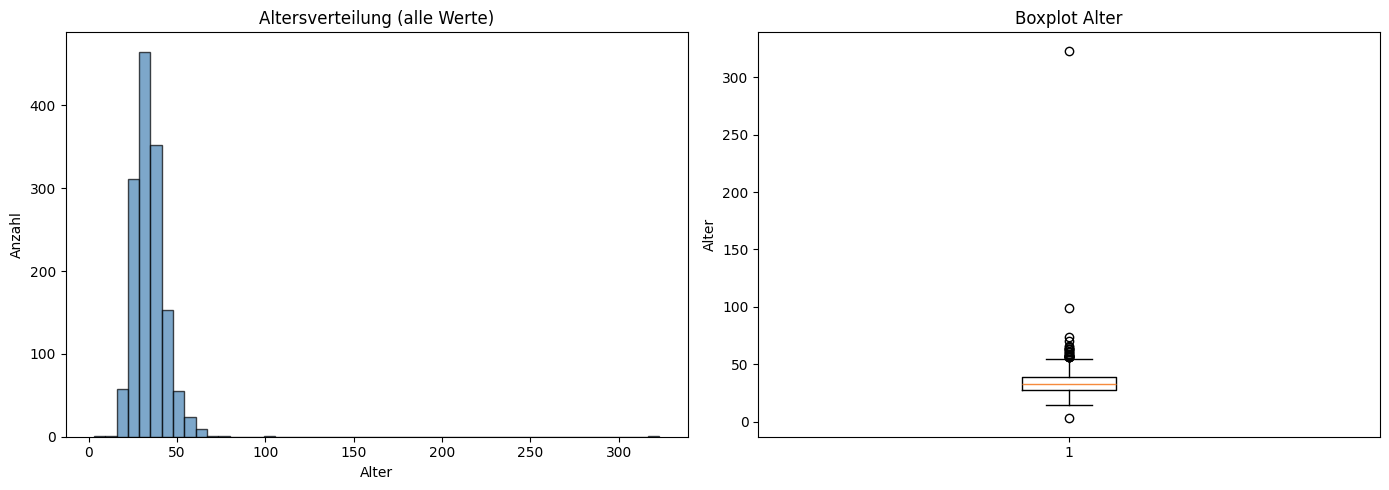

In [11]:
# Altersverteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm (alle Werte)
axes[0].hist(df['age'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Alter')
axes[0].set_ylabel('Anzahl')
axes[0].set_title('Altersverteilung (alle Werte)')

# Boxplot
axes[1].boxplot(df['age'].dropna(), vert=True)
axes[1].set_ylabel('Alter')
axes[1].set_title('Boxplot Alter')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_age.png", dpi=150)
plt.show()

In [12]:
# Ausreisser
outliers = df[(df['age'] < 18) | (df['age'] > 80)]
print(f"Ausreisser (< 18 oder > 80): {len(outliers)}")
print(f"Werte: {sorted(outliers['age'].unique())}")

Ausreisser (< 18 oder > 80): 5
Werte: [np.int64(3), np.int64(15), np.int64(17), np.int64(99), np.int64(323)]


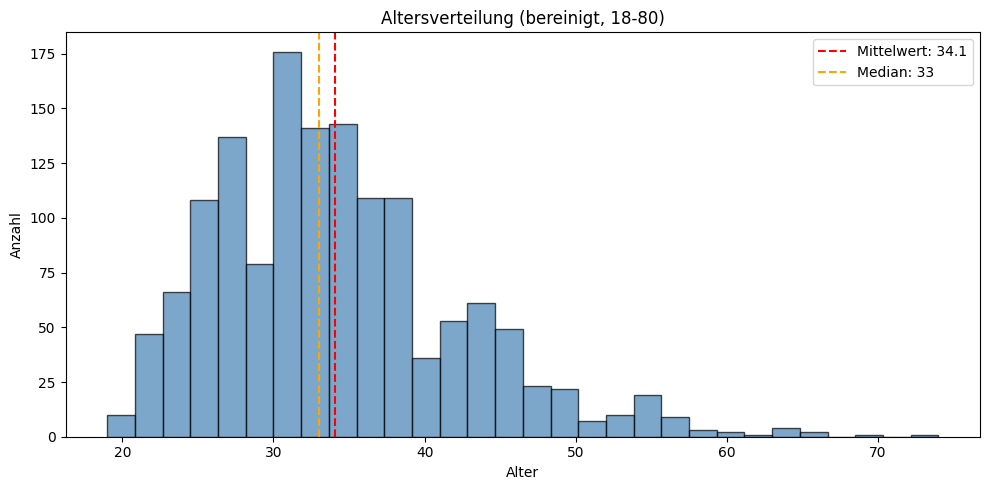

In [13]:
# Altersverteilung ohne Ausreisser
ages_clean = df['age'][(df['age'] >= 18) & (df['age'] <= 80)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ages_clean, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Alter')
ax.set_ylabel('Anzahl')
ax.set_title('Altersverteilung (bereinigt, 18-80)')
ax.axvline(ages_clean.mean(), color='red', linestyle='--', label=f'Mittelwert: {ages_clean.mean():.1f}')
ax.axvline(ages_clean.median(), color='orange', linestyle='--', label=f'Median: {ages_clean.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_age.png", dpi=150)
plt.show()

#### 7. Gender = Freitext
- muss später vereinheitlicht werden

In [14]:
print(f"Anzahl unique Rohwerte: {df['gender'].nunique()}")
print(f"Fehlende Werte: {df['gender'].isnull().sum()}")
print(f"\nAlle Werte und Haeufigkeiten:")
print(df['gender'].value_counts().to_string())

Anzahl unique Rohwerte: 70
Fehlende Werte: 3

Alle Werte und Haeufigkeiten:
gender
Male                                                                                                                                                             610
male                                                                                                                                                             249
Female                                                                                                                                                           153
female                                                                                                                                                            95
M                                                                                                                                                                 86
m                                                                                           

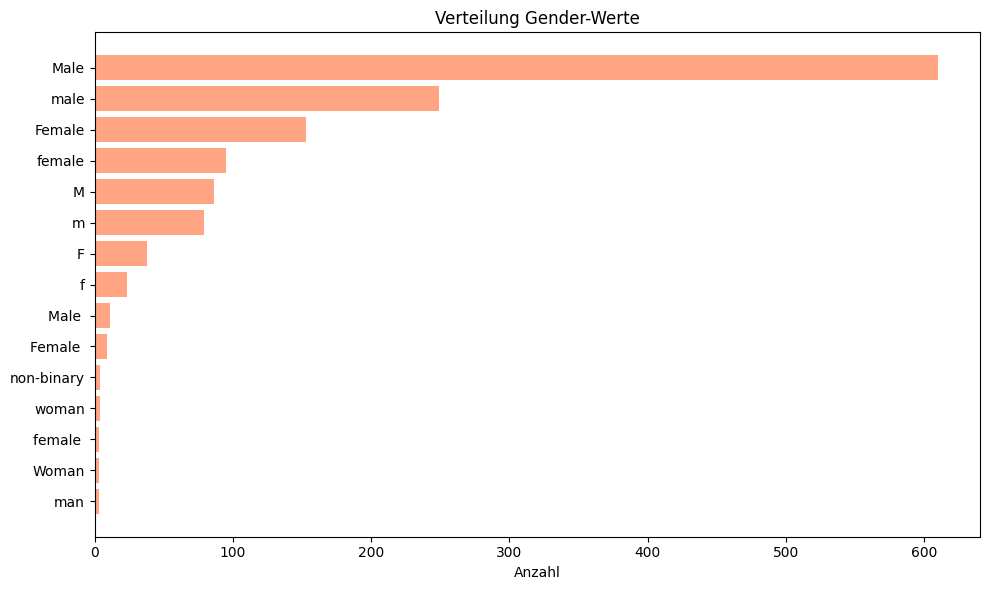

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
top_gender = df['gender'].value_counts().head(15)
ax.barh(range(len(top_gender)), top_gender.values, color='coral', alpha=0.7)
ax.set_yticks(range(len(top_gender)))
ax.set_yticklabels(top_gender.index)
ax.set_xlabel('Anzahl')
ax.set_title('Verteilung Gender-Werte')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_gender.png", dpi=150)
plt.show()

#### 8. Geographische Verteilung
- Regionen aggregieren?

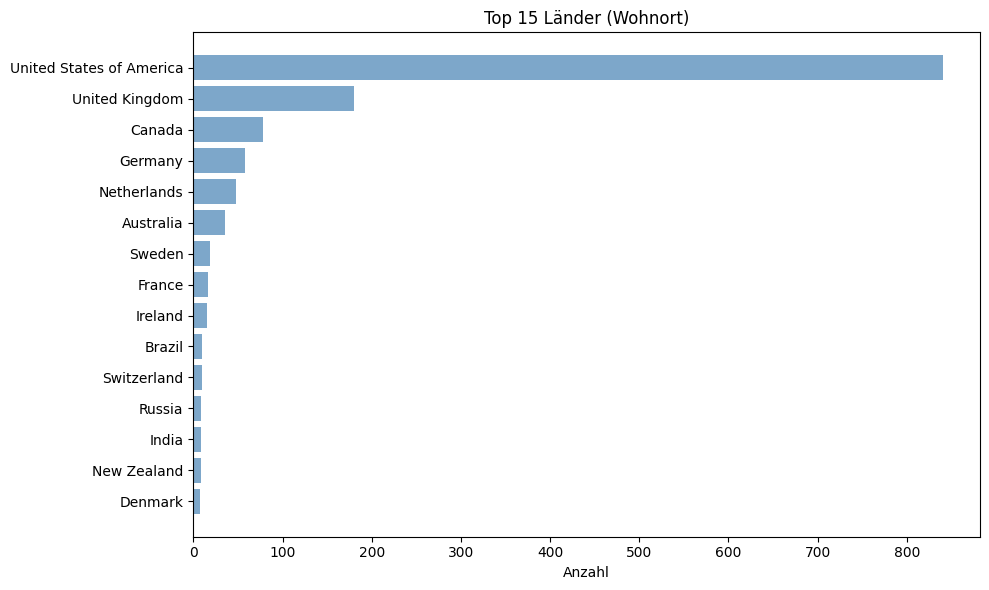


Anzahl verschiedene Laender: 53
Anteil USA: 58.6%


In [16]:
# Top-15 Laender
fig, ax = plt.subplots(figsize=(10, 6))
countries = df['country_live'].value_counts().head(15)
ax.barh(range(len(countries)), countries.values, color='steelblue', alpha=0.7)
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries.index)
ax.set_xlabel('Anzahl')
ax.set_title('Top 15 Länder (Wohnort)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_country_live.png", dpi=150)
plt.show()

print(f"\nAnzahl verschiedene Laender: {df['country_live'].nunique()}")
print(f"Anteil USA: {(df['country_live'] == 'United States of America').sum() / len(df) * 100:.1f}%")

#### 9. Wer ist in Behandlung?

In [17]:
# Kreuztabelle: Aktuelle Stoerung vs. Behandlung gesucht
ct = pd.crosstab(df['current_disorder'], df['sought_treatment'], margins=True)
print("Aktuelle MH-Störung vs. Behandlung gesucht:")
print(ct)

Aktuelle MH-Störung vs. Behandlung gesucht:
sought_treatment    0    1   All
current_disorder                
Maybe             145  182   327
No                390  141   531
Yes                59  516   575
All               594  839  1433


#### 10. Negative Konsequenzen bei Gespräch mit AG befürchtet

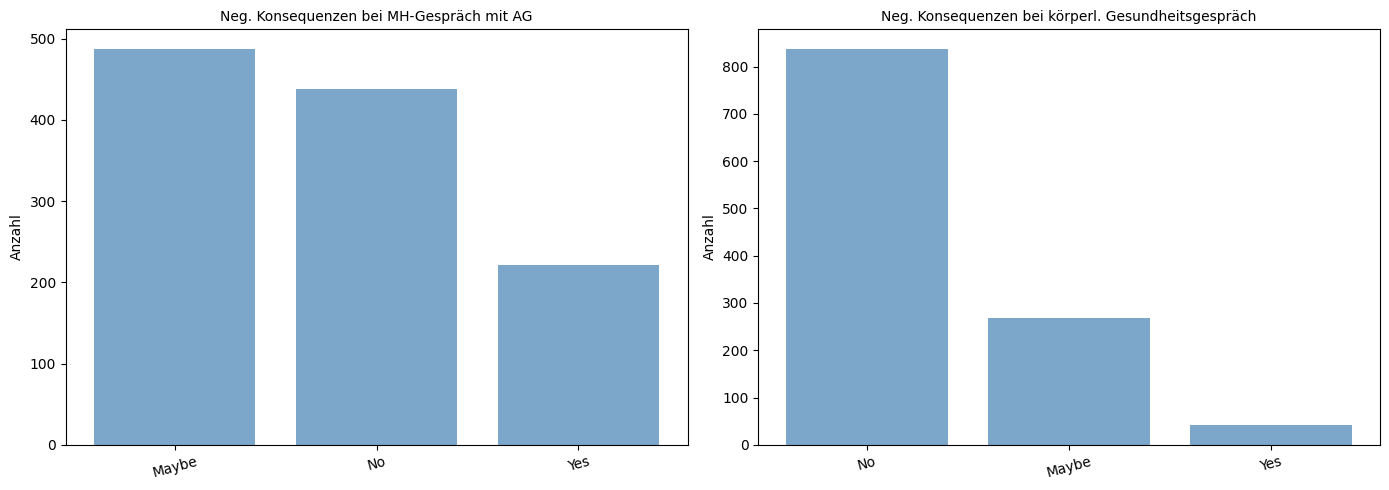

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, title) in enumerate([
    ('neg_consequences_employer', 'Neg. Konsequenzen bei MH-Gespräch mit AG'),
    ('neg_consequences_physical', 'Neg. Konsequenzen bei körperl. Gesundheitsgespräch')
]):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].bar(range(len(counts)), counts.values, color='steelblue', alpha=0.7)
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=15)
        axes[i].set_title(title, fontsize=10)
        axes[i].set_ylabel('Anzahl')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_neg_consequences_employer.png", dpi=150)
plt.show()

#### 11. Andere Verteilungen prüfen:
Selbstständige, Unternehmensgröße, Unterstützung durch AG bei MH Problemen, Erwartete Konsequenzen, ...

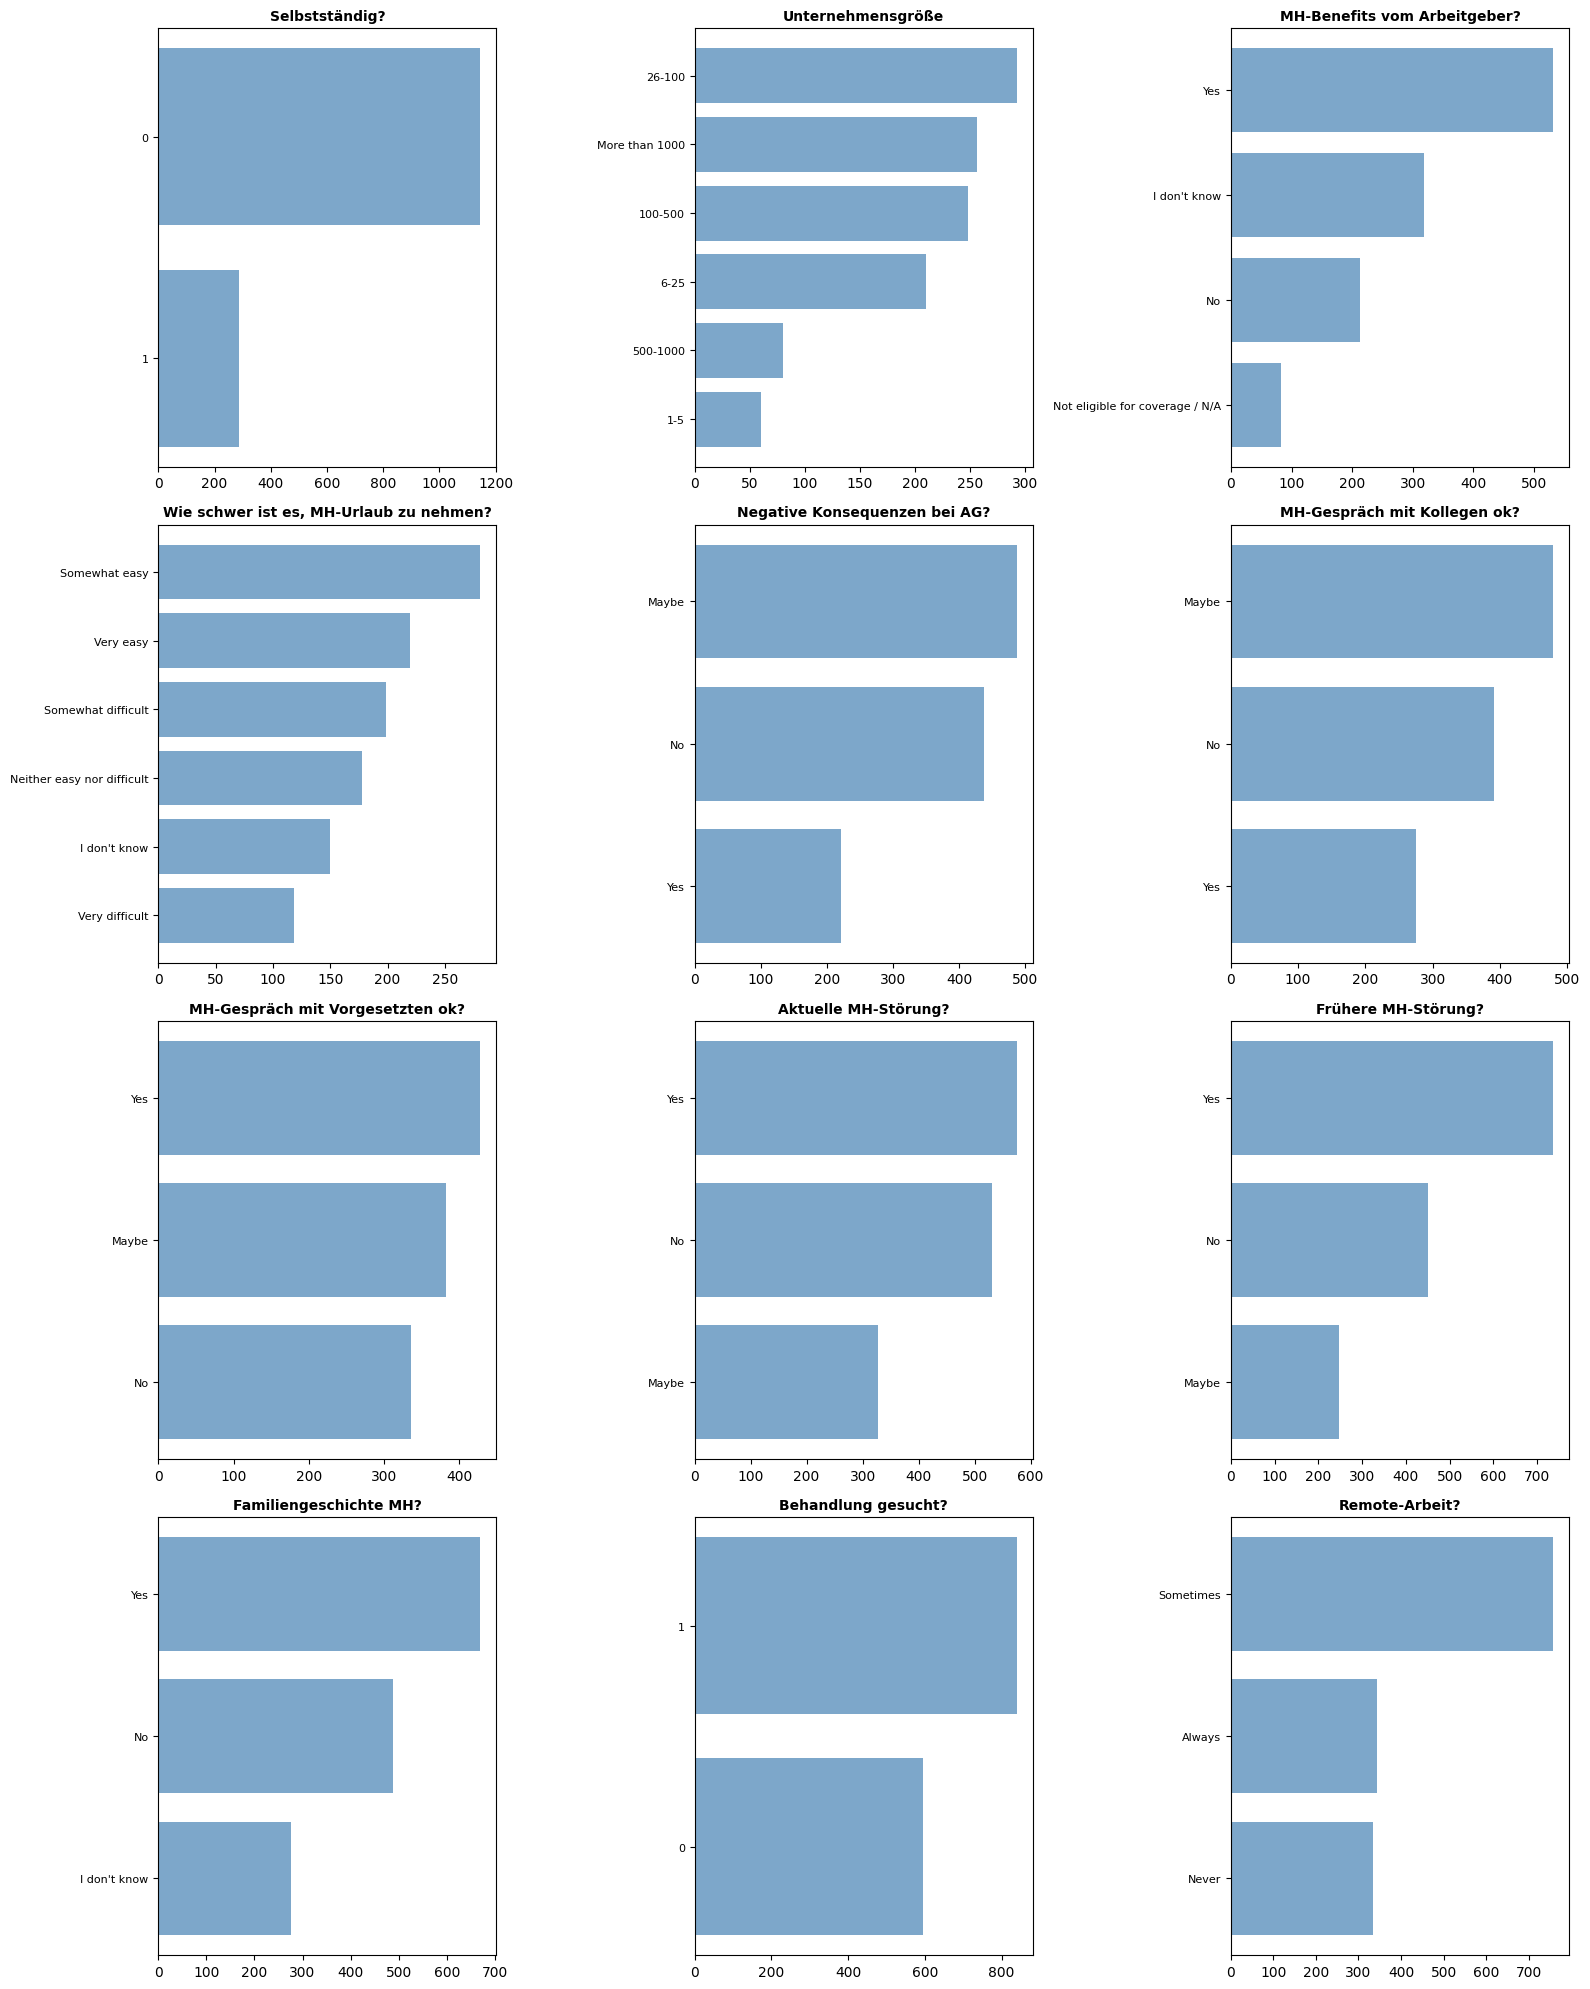

In [19]:
# Auswahl relevanter Spalten fuer Visualisierung
plot_cols = [
    ('self_employed', 'Selbstständig?'),
    ('company_size', 'Unternehmensgröße'),
    ('mh_benefits', 'MH-Benefits vom Arbeitgeber?'),
    ('leave_difficulty', 'Wie schwer ist es, MH-Urlaub zu nehmen?'),
    ('neg_consequences_employer', 'Negative Konsequenzen bei AG?'),
    ('comfortable_coworkers', 'MH-Gespräch mit Kollegen ok?'),
    ('comfortable_supervisor', 'MH-Gespräch mit Vorgesetzten ok?'),
    ('current_disorder', 'Aktuelle MH-Störung?'),
    ('past_disorder', 'Frühere MH-Störung?'),
    ('family_history', 'Familiengeschichte MH?'),
    ('sought_treatment', 'Behandlung gesucht?'),
    ('remote_work', 'Remote-Arbeit?'),
]

fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, (col, title) in enumerate(plot_cols):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].barh(range(len(counts)), counts.values, color='steelblue', alpha=0.7)
        axes[i].set_yticks(range(len(counts)))
        axes[i].set_yticklabels(counts.index, fontsize=8)
        axes[i].set_title(title, fontsize=10, fontweight='bold')
        axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_overview.png", dpi=150)
plt.show()

In [20]:
import io

report_lines = []

def h(text, level=2):
    report_lines.append(f"{'#' * level} {text}")

def p(text):
    report_lines.append(str(text))

def fig_ref(filename, caption=""):
    report_lines.append(f"![{caption}](figures/eda/{filename})")

# Datenstruktur
h("Datenstruktur", 2)
p(f"**Zeilen:** {df.shape[0]}  \n**Spalten:** {df.shape[1]}")
buf = io.StringIO()
df.info(buf=buf)
p("```")
p(buf.getvalue())
p("```")

# Fehlende Werte
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Fehlend": missing, "Prozent": missing_pct}).sort_values("Fehlend", ascending=False)
h("Fehlende Werte", 2)
p("| Spalte | Fehlend | Prozent |")
p("|--------|---------|---------|")
for col, row in missing_df[missing_df["Fehlend"] > 0].iterrows():
    p(f"| {col} | {int(row['Fehlend'])} | {row['Prozent']}% |")
n_self = (df["self_employed"] == 1).sum()
n_miss = df["company_size"].isnull().sum()
p(f"\nSelbstständige: {n_self} | Fehlende Werte bei `company_size`: {n_miss} | Übereinstimmung: {n_self == n_miss}")
fig_ref("missing_values.png", "Fehlende Werte pro Spalte")

# Datentypen
h("Datentypen", 2)
p("```")
p(str(df.dtypes.value_counts()))
p(f"\nGesamtzahl Spalten: {len(df.columns)}")
p("```")

# Alter
h("Alter", 2)
age_desc = df["age"].describe()
p("| | Wert |")
p("|--|------|")
for idx, val in age_desc.items():
    p(f"| {idx} | {val:.2f} |")
outliers = df[(df["age"] < 18) | (df["age"] > 80)]
p(f"\nAusreißer (< 18 oder > 80): {len(outliers)} | Werte: {sorted(int(x) for x in outliers['age'].unique())}")
fig_ref("dist_age.png", "Altersverteilung")

# Gender
def detect_gender_issues(df):
    normalized = {}
    for val in df["gender"].dropna().unique():
        key = str(val).strip().lower()
        normalized.setdefault(key, []).append(val)
    return normalized

gender_map = detect_gender_issues(df)
h("Gender", 2)
p(f"Unique Rohwerte: {df['gender'].nunique()} | Fehlende Werte: {df['gender'].isnull().sum()}")
p(f"Unique nach Normalisierung (lowercase/strip): {len(gender_map)}")
p("")
p("| Normalisiert | Rohwerte |")
p("|-------------|----------|")
for key in sorted(gender_map.keys()):
    vals = ", ".join(f"`{v}`" for v in gender_map[key])
    p(f"| {key} | {vals} |")
fig_ref("dist_gender.png", "Gender-Verteilung (Top 15)")

# Geographische Verteilung
h("Geographische Verteilung", 2)
p(f"Verschiedene Länder: {df['country_live'].nunique()} | Anteil USA: {(df['country_live'] == 'United States of America').sum() / len(df) * 100:.1f}%")
fig_ref("dist_country_live.png", "Top 15 Länder (Wohnort)")

# Crosstab
h("Aktuelle MH-Störung vs. Behandlung gesucht", 2)
ct = pd.crosstab(df["current_disorder"], df["sought_treatment"], margins=True)
cols = ct.columns.tolist()
p("| | " + " | ".join(str(c) for c in cols) + " |")
p("|--" + "|--" * len(cols) + "|")
for idx, row in ct.iterrows():
    p("| " + str(idx) + " | " + " | ".join(str(row[c]) for c in cols) + " |")

# Negative Konsequenzen
h("Negative Konsequenzen bei Gespräch mit Arbeitgeber", 2)
fig_ref("dist_neg_consequences_employer.png", "Negative Konsequenzen MH vs. körperliche Gesundheit")

# Weitere Verteilungen
h("Weitere Verteilungen", 2)
fig_ref("dist_overview.png", "Verteilung ausgewählter Variablen")

# Report schreiben
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("# EDA Report – OSMI Mental Health in Tech Survey 2016\n\n")
    for line in report_lines:
        f.write(line + "\n")

print(f"Report gespeichert: {REPORT_PATH}")


Report gespeichert: ..\documentation\eda_report.md


In [22]:
# Häufigkeiten und Prozente für alle Spalten mit <= 5 eindeutigen Werten
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) <= 5:
        print(f"\n{col} (n={df[col].notna().sum()}):")
        for val in sorted(unique_vals):
            n = (df[col] == val).sum()
            pct = n / df[col].notna().sum() * 100
            print(f"  {val}: {n} ({pct:.1f} %)")


self_employed (n=1433):
  0: 1146 (80.0 %)
  1: 287 (20.0 %)

tech_company (n=1146):
  0.0: 263 (22.9 %)
  1.0: 883 (77.1 %)

tech_role (n=263):
  0.0: 15 (5.7 %)
  1.0: 248 (94.3 %)

mh_benefits (n=1146):
  I don't know: 319 (27.8 %)
  No: 213 (18.6 %)
  Not eligible for coverage / N/A: 83 (7.2 %)
  Yes: 531 (46.3 %)

know_options (n=1013):
  I am not sure: 352 (34.7 %)
  No: 354 (34.9 %)
  Yes: 307 (30.3 %)

employer_discussed_mh (n=1146):
  I don't know: 103 (9.0 %)
  No: 813 (70.9 %)
  Yes: 230 (20.1 %)

employer_resources (n=1146):
  I don't know: 320 (27.9 %)
  No: 531 (46.3 %)
  Yes: 295 (25.7 %)

anonymity_protected (n=1146):
  I don't know: 742 (64.7 %)
  No: 84 (7.3 %)
  Yes: 320 (27.9 %)

neg_consequences_employer (n=1146):
  Maybe: 487 (42.5 %)
  No: 438 (38.2 %)
  Yes: 221 (19.3 %)

neg_consequences_physical (n=1146):
  Maybe: 268 (23.4 %)
  No: 837 (73.0 %)
  Yes: 41 (3.6 %)

comfortable_coworkers (n=1146):
  Maybe: 479 (41.8 %)
  No: 392 (34.2 %)
  Yes: 275 (24.0 %)

co

In [21]:
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment

def write_excel(df):
    output_path = Path("../documentation/eda_analysis_01.xlsx")
    wb = Workbook()
    ws = wb.active
    ws.title = "Spalten-Uebersicht"

    bold   = Font(bold=True, size=11, name="Arial")
    normal = Font(size=11, name="Arial")
    left   = Alignment(horizontal="left")

    freetext_cols = [
        "interview_physical_why", "interview_mental_why", "diagnosed_conditions",
        "believed_conditions", "professional_diagnosis_detail", "work_position",
    ]

    headers = ["Spalte", "Typ", "Datentyp", "Unique", "Fehlend", "Fehlend %", "Haeufigster Wert", "Anzahl"]
    for ci, val in enumerate(headers, 1):
        c = ws.cell(row=1, column=ci, value=val)
        c.font = bold
        c.alignment = left

    for ri, col in enumerate(df.columns, 2):
        s = df[col]
        vc = s.value_counts()
        top_val = vc.index[0] if not vc.empty else ""
        top_cnt = int(vc.iloc[0]) if not vc.empty else ""
        if col == "age":
            col_type = "numeric"
        elif col in freetext_cols:
            col_type = "freetext"
        else:
            col_type = "categorical"
        values = [
            col, col_type, str(s.dtype), s.nunique(),
            int(s.isnull().sum()),
            round(s.isnull().sum() / len(df) * 100, 1),
            str(top_val), top_cnt,
        ]
        for ci, val in enumerate(values, 1):
            c = ws.cell(row=ri, column=ci, value=val)
            c.font = normal
            c.alignment = left

    for ci in range(1, len(headers) + 1):
        ws.column_dimensions[ws.cell(row=1, column=ci).column_letter].width = max(
            len(str(ws.cell(row=1, column=ci).value)) + 4, 14
        )

    wb.save(output_path)
    print(f"Excel gespeichert: {output_path}")

write_excel(df)

Excel gespeichert: ..\documentation\eda_analysis_01.xlsx
